# Final Project - Machine Learning Research and Implementation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##1. Data Preprocessing

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df_bak = df.copy()

| # | Column | Description | Dtype |
|---|---|---|---|
| 0 |  battery_power | Total energy a battery can store in one time measured in mAh |int64 |
| 1 |  blue          | Has bluetooth or not  | int64 (0or1)  |
| 2 |  clock_speed   | speed at which microprocessor executes instructions  | float64|
| 3 |  dual_sim      | Has dual sim support or not  | int64 (0or1)  |
| 4 |  fc            | Front Camera mega pixels  | int64  |
| 5 |  four_g        | Has 4G or not  | int64(0or1)  |
| 6 |  int_memory    | Internal Memory in Gigabytes  | int64  |
| 7 |  m_dep         | Mobile Depth in cm  | float64|
| 8 |  mobile_wt     | Weight of mobile phone  | int64  |
| 9 |  n_cores       | Number of cores of processor  | int64  |
| 10 | pc            | Primary Camera mega pixels  | int64  |
| 11 | px_height     | Pixel Resolution Height  | int64  |
| 12 | px_width      | Pixel Resolution Width  | int64  |
| 13 | ram           | Random Access Memory in Mega Bytes  | int64  |
| 14 | sc_h          | Screen Height of mobile in cm  | int64  |
| 15 | sc_w          | Screen Width of mobile in cm  | int64  |
| 16 | talk_time     | longest time that a single battery charge will last when you are  | int64  |
| 17 | three_g       | Has 3G or not  | int64(0or1)  |
| 18 | touch_screen  | Has touch screen or not  | int64(0or1)  |
| 19 | wifi          | Has wifi or not  | int64(0or1)  |
| 20 | **price_range**   | This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost).  | int64(0 to 3)  |

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.columns:
  print(f'{col}, {df[col].unique()}')

battery_power, [ 842 1021  563 ... 1139 1467  858]
blue, [0 1]
clock_speed, [2.2 0.5 2.5 1.2 1.7 0.6 2.9 2.8 2.1 1.  0.9 1.1 2.6 1.4 1.6 2.7 1.3 2.3
 2.  1.8 3.  1.5 1.9 2.4 0.8 0.7]
dual_sim, [0 1]
fc, [ 1  0  2 13  3  4  5  7 11 12 16  6 15  8  9 10 18 17 14 19]
four_g, [0 1]
int_memory, [ 7 53 41 10 44 22 24  9 33 17 52 46 13 23 49 19 39 47 38  8 57 51 21  5
 60 61  6 11 50 34 20 27 42 40 64 14 63 43 16 48 12 55 36 30 45 29 58 25
  3 54 15 37 31 32  4 18  2 56 26 35 59 28 62]
m_dep, [0.6 0.7 0.9 0.8 0.1 0.5 1.  0.3 0.4 0.2]
mobile_wt, [188 136 145 131 141 164 139 187 174  93 182 177 159 198 185 196 121 101
  81 156 199 114 111 132 143  96 200  88 150 107 100 157 160 119  87 152
 166 110 118 162 127 109 102 104 148 180 128 134 144 168 155 165  80 138
 142  90 197 172 116  85 163 178 171 103  83 140 194 146 192 106 135 153
  89  82 130 189 181  99 184 195 108 133 179 147 137 190 176  84  97 124
 183 113  92  95 151 117  94 173 105 115  91 112 123 129 154 191 175  86
  98 125 126 158 1

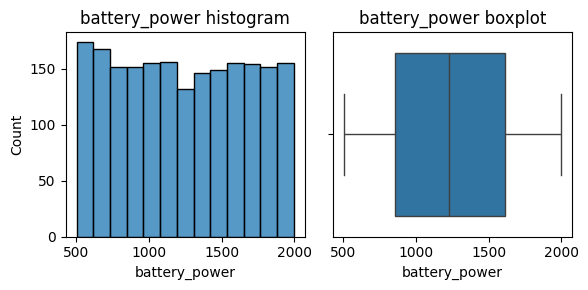

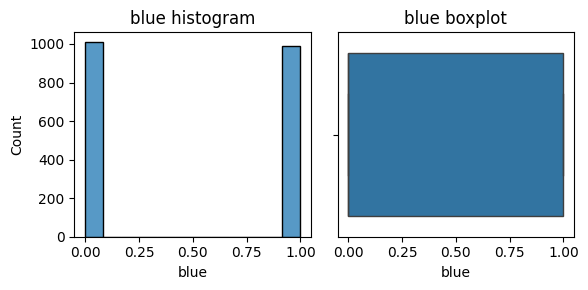

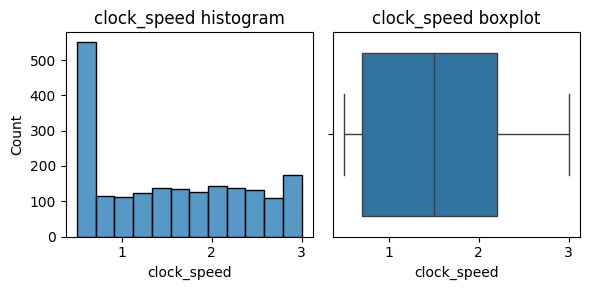

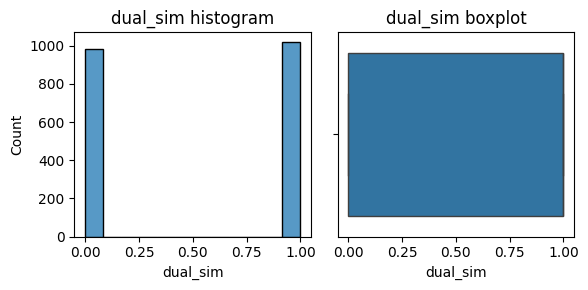

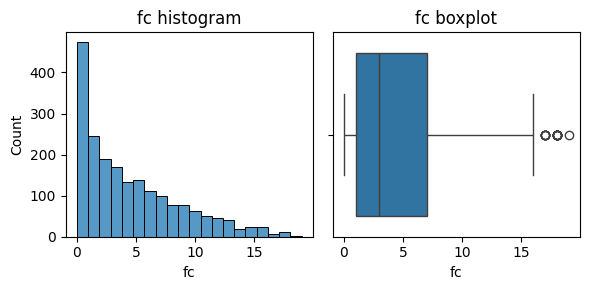

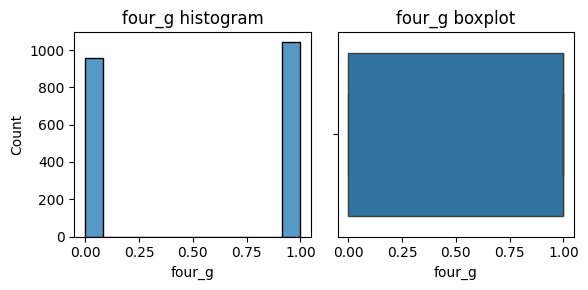

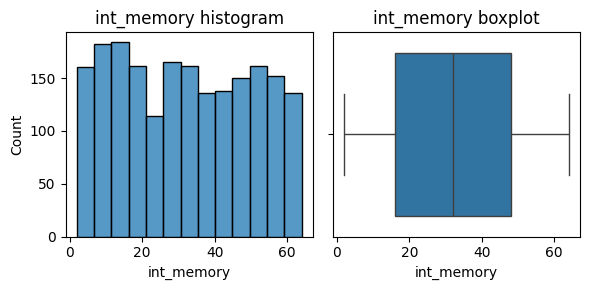

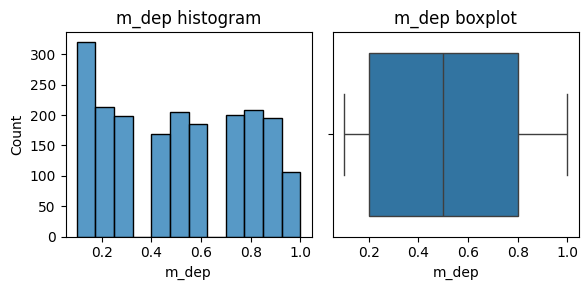

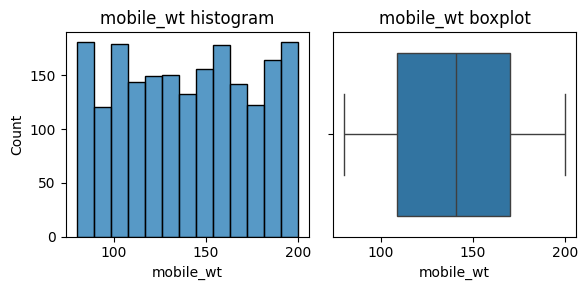

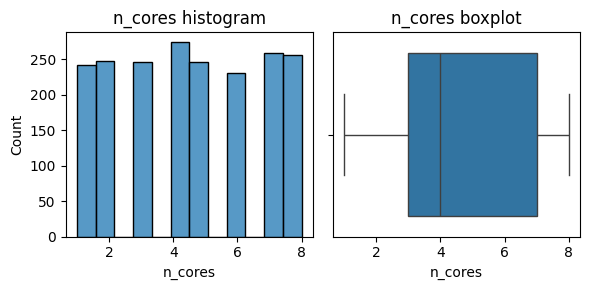

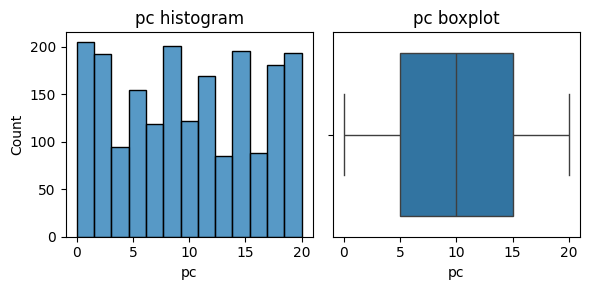

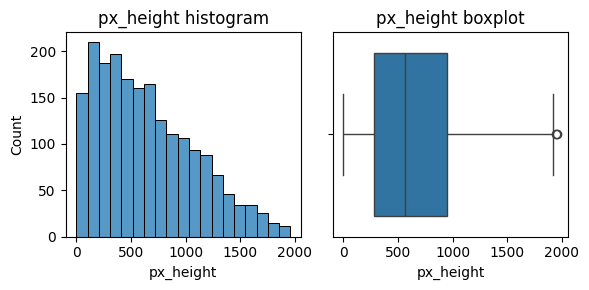

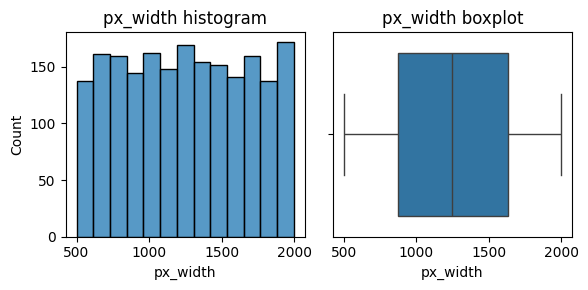

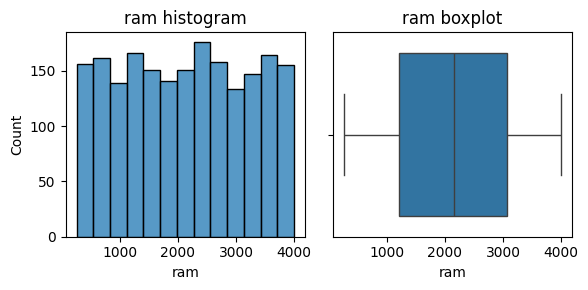

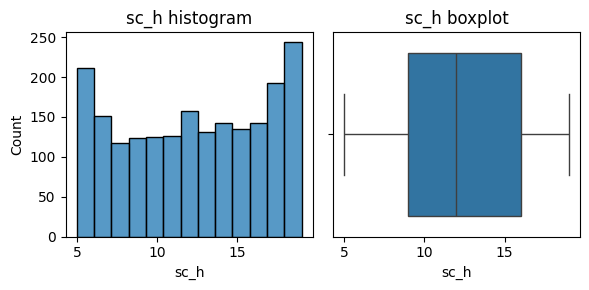

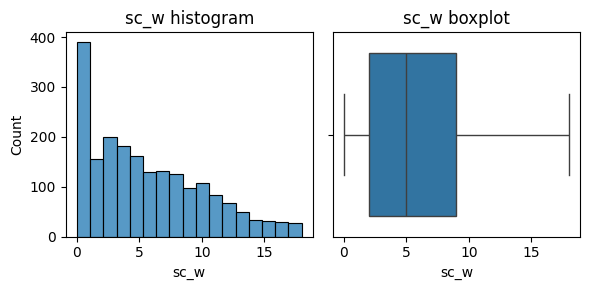

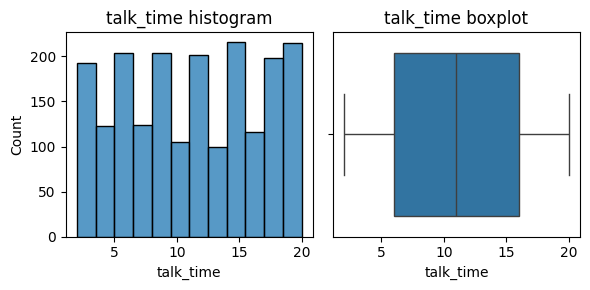

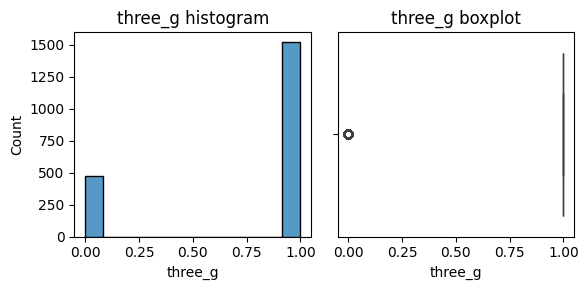

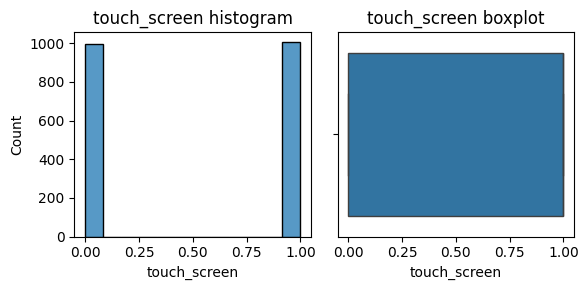

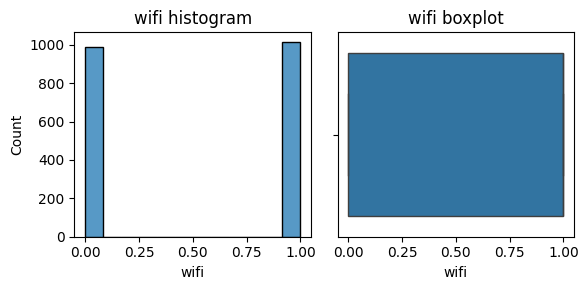

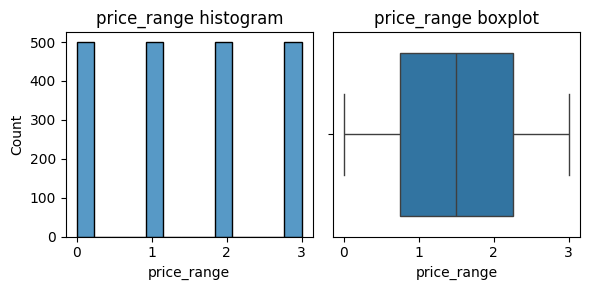

In [ ]:

for col in df.columns:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,3))
  sns.histplot(data=df, x=col, ax=ax1)
  ax1.set_title(f'{col} histogram')

  sns.boxplot(data=df, x=col, ax=ax2)
  ax2.set_title(f'{col} boxplot')

  plt.tight_layout()
  plt.show()

## Data Splite
- 5 Fold (1600 train + 400 test)


##Tunning

In [ ]:
# ============================================
# 1. Libraries
# ============================================

from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials


# ============================================
# 2. Dataset
# ============================================

X = df.drop("price_range", axis=1)
y = df["price_range"]


# ============================================
# 3. 5-Fold Cross Validation
# ============================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================
# 4. Baseline SVM
# ============================================

baseline_results = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # SVM
    model = SVC()

    # Training
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    baseline_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, average="macro"
        ),
        "recall": recall_score(
            y_test, y_pred, average="macro"
        ),
        "f1": f1_score(
            y_test, y_pred, average="macro"
        )
    })


baseline_df = pd.DataFrame(baseline_results)

print("Baseline SVM")
display(baseline_df)

print("\nMean:")
print(baseline_df.mean(numeric_only=True))


# ============================================
# 5. Hyperopt Search Space
# ============================================

space = {
    "kernel": hp.choice(
        "kernel",
        ["linear", "poly", "rbf", "sigmoid"]
    ),

    "C": hp.uniform(
        "C",
        0.01,
        100
    ),

    "gamma": hp.uniform(
        "gamma",
        4.701e-7,
        6.701e-7
    ),

    "decision_function_shape": hp.choice(
        "decision_function_shape",
        ["ovo", "ovr"]
    )
}


# ============================================
# 6. Hyperopt
# ============================================

hyperopt_results = []
hyperopt_trials = []

for fold, (train_index, test_index) in enumerate(
    skf.split(X, y), 1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]


    # ----------------------------------------
    # Objective Function
    # ----------------------------------------

    def objective(params):

        model = SVC(
            kernel=params["kernel"],
            C=params["C"],
            gamma=params["gamma"],
            decision_function_shape=params[
                "decision_function_shape"
            ]
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        return {
            "loss": -accuracy,
            "status": STATUS_OK
        }


    # ----------------------------------------
    # Hyperopt
    # ----------------------------------------

    trials = Trials()

    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=100,
        trials=trials
    )

    # Save trials
    hyperopt_trials.append(trials)


    # ----------------------------------------
    # Convert hp.choice index to value
    # ----------------------------------------

    kernels = [
        "linear",
        "poly",
        "rbf",
        "sigmoid"
    ]

    decision_shapes = [
        "ovo",
        "ovr"
    ]

    best_params = {
        "kernel": kernels[best["kernel"]],
        "C": best["C"],
        "gamma": best["gamma"],
        "decision_function_shape":
            decision_shapes[
                best["decision_function_shape"]
            ]
    }


    # ----------------------------------------
    # Train final model
    # ----------------------------------------

    final_model = SVC(
        **best_params
    )

    final_model.fit(
        X_train,
        y_train
    )

    y_pred = final_model.predict(
        X_test
    )


    # ----------------------------------------
    # Evaluation
    # ----------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )


    hyperopt_results.append({
        "fold": fold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "kernel": best_params["kernel"],
        "C": best_params["C"],
        "gamma": best_params["gamma"],
        "decision_function_shape":
            best_params[
                "decision_function_shape"
            ]
    })


    print("Best parameters:")
    print(best_params)

    print(f"Accuracy: {accuracy:.4f}")


# ============================================
# 7. Hyperopt Results
# ============================================

hyperopt_df = pd.DataFrame(
    hyperopt_results
)

print("\nHyperopt Results")
display(hyperopt_df)

print("\nMean:")
print(
    hyperopt_df.mean(
        numeric_only=True
    )
)

Baseline SVM


,fold,accuracy,precision,recall,f1
0,1,0.9600,0.961029,0.9600,0.959502
1,2,0.9700,0.971284,0.9700,0.969817
2,3,0.9450,0.945273,0.9450,0.945018
3,4,0.9375,0.938393,0.9375,0.937033
4,5,0.9450,0.945994,0.9450,0.944845



Mean:
fold         3.000000
accuracy     0.951500
precision    0.952395
recall       0.951500
f1           0.951243
dtype: float64

========== Fold 1 ==========
100%|██████████| 100/100 [03:15<00:00,  1.95s/trial, best loss: -0.975]
Best parameters:
{'kernel': 'rbf', 'C': np.float64(75.07627328505123), 'gamma': np.float64(5.495314258490123e-07), 'decision_function_shape': 'ovr'}
Accuracy: 0.9750

========== Fold 2 ==========
100%|██████████| 100/100 [27:09<00:00, 16.29s/trial, best loss: -0.9825]
Best parameters:
{'kernel': 'linear', 'C': np.float64(16.678831892373218), 'gamma': np.float64(6.464780991342871e-07), 'decision_function_shape': 'ovo'}
Accuracy: 0.9825

========== Fold 3 ==========
100%|██████████| 100/100 [16:01<00:00,  9.62s/trial, best loss: -0.9675]
Best parameters:
{'kernel': 'linear', 'C': np.float64(64.29054646962668), 'gamma': np.float64(6.348532100684474e-07), 'decision_function_shape': 'ovo'}
Accuracy: 0.9675

========== Fold 4 ==========
100%|██████████| 100/100 

,fold,accuracy,precision,recall,f1,kernel,C,gamma,decision_function_shape
0,1,0.9750,0.975406,0.9750,0.974889,rbf,75.076273,5.495314e-07,ovr
1,2,0.9825,0.982714,0.9825,0.982497,linear,16.678832,6.464781e-07,ovo
2,3,0.9675,0.967643,0.9675,0.967511,linear,64.290546,6.348532e-07,ovo
3,4,0.9775,0.977770,0.9775,0.977548,poly,20.303879,6.082206e-07,ovr
4,5,0.9775,0.977499,0.9775,0.977487,poly,52.683229,4.938537e-07,ovo



Mean:
fold         3.000000e+00
accuracy     9.760000e-01
precision    9.762064e-01
recall       9.760000e-01
f1           9.759864e-01
C            4.580655e+01
gamma        5.865874e-07
dtype: float64


In [ ]:
comparison = pd.DataFrame({
    "Baseline SVM": baseline_df["accuracy"],
    "SVM + Hyperopt": hyperopt_df["accuracy"]
})

display(comparison)

,Baseline SVM,SVM + Hyperopt
0,0.9600,0.9750
1,0.9700,0.9825
2,0.9450,0.9675
3,0.9375,0.9775
4,0.9450,0.9775


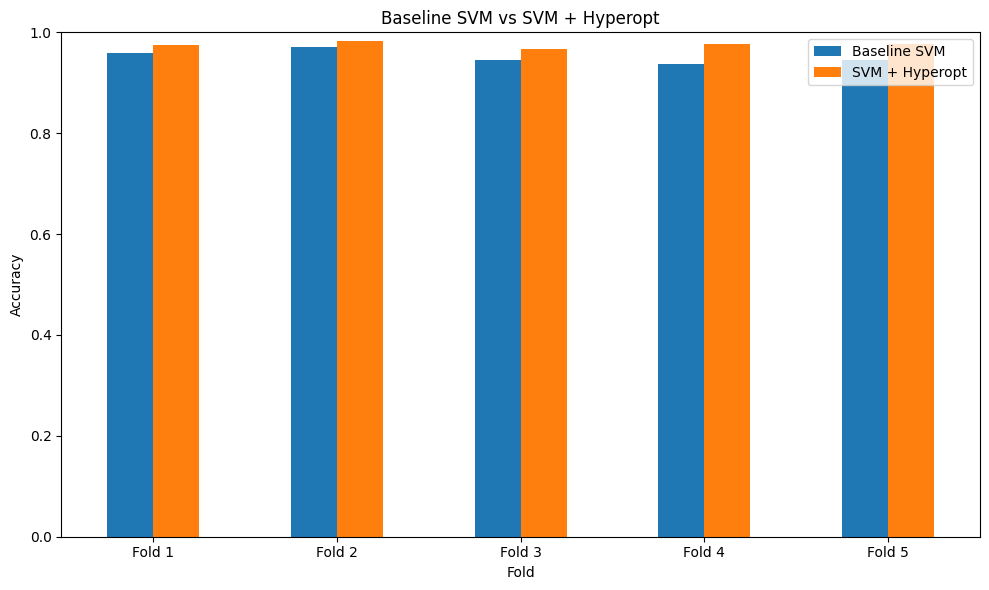

In [ ]:
comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Baseline SVM vs SVM + Hyperopt"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(
    range(5),
    [f"Fold {i}" for i in range(1, 6)],
    rotation=0
)

plt.tight_layout()
plt.show()

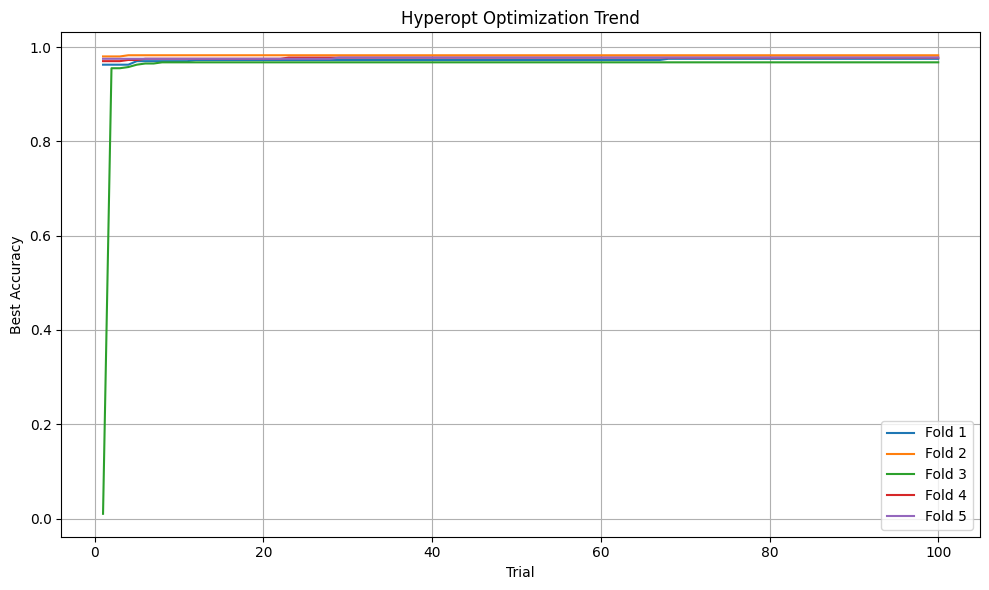

In [ ]:
plt.figure(figsize=(10, 6))

for i, trials in enumerate(
    hyperopt_trials,
    1
):

    trial_accuracy = [
        -trial["result"]["loss"]
        for trial in trials.trials
    ]

    best_so_far = []
    current_best = 0

    for acc in trial_accuracy:

        current_best = max(
            current_best,
            acc
        )

        best_so_far.append(
            current_best
        )

    plt.plot(
        range(1, len(best_so_far) + 1),
        best_so_far,
        label=f"Fold {i}"
    )


plt.xlabel("Trial")
plt.ylabel("Best Accuracy")

plt.title(
    "Hyperopt Optimization Trend"
)

plt.legend()

plt.grid()

plt.tight_layout()
plt.show()

## Optuna

In [ ]:
!pip install optuna -q

import optuna
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 17.5 MB/s eta 0:00:00


In [ ]:
optuna_results = []
optuna_studies = []

for fold, (train_index, test_index) in enumerate(
    skf.split(X, y), 1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # ----------------------------------------
    # Objective Function
    # ----------------------------------------

    def objective(trial):

        kernel = trial.suggest_categorical(
            "kernel",
            ["linear", "poly", "rbf", "sigmoid"]
        )

        C = trial.suggest_float(
            "C",
            0.01,
            100
        )

        gamma = trial.suggest_float(
            "gamma",
            4.701e-7,
            6.701e-7
        )

        decision_function_shape = trial.suggest_categorical(
            "decision_function_shape",
            ["ovo", "ovr"]
        )

        model = SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            decision_function_shape=decision_function_shape
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        # Optuna: maximize accuracy
        return accuracy


    # ----------------------------------------
    # Create Study
    # ----------------------------------------

    study = optuna.create_study(
        direction="maximize"
    )

    # 100 trials
    study.optimize(
        objective,
        n_trials=100
    )

    # Save study
    optuna_studies.append(study)


    # ----------------------------------------
    # Best Parameters
    # ----------------------------------------

    best_params = study.best_params

    print("Best parameters:")
    print(best_params)

    print(f"Best CV accuracy: {study.best_value:.4f}")


    # ----------------------------------------
    # Train final SVM
    # ----------------------------------------

    final_model = SVC(
        **best_params
    )

    final_model.fit(
        X_train,
        y_train
    )

    y_pred = final_model.predict(
        X_test
    )


    # ----------------------------------------
    # Evaluation
    # ----------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )


    optuna_results.append({
        "fold": fold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "kernel": best_params["kernel"],
        "C": best_params["C"],
        "gamma": best_params["gamma"],
        "decision_function_shape":
            best_params["decision_function_shape"]
    })

    print(f"Test Accuracy: {accuracy:.4f}")

[I 2026-08-24 20:12:21,782] A new study created in memory with name: no-name-aea342f4-899e-4a3e-9885-8455ca352e94



========== Fold 1 ==========


[I 2026-08-24 20:12:34,688] Trial 0 finished with value: 0.96 and parameters: {'kernel': 'linear', 'C': 97.25760130926352, 'gamma': 5.140722289248539e-07, 'decision_function_shape': 'ovr'}. Best is trial 0 with value: 0.96.
[I 2026-08-24 20:12:34,721] Trial 1 finished with value: 0.965 and parameters: {'kernel': 'poly', 'C': 42.568148176040225, 'gamma': 5.192468666059747e-07, 'decision_function_shape': 'ovo'}. Best is trial 1 with value: 0.965.
[I 2026-08-24 20:12:34,748] Trial 2 finished with value: 0.97 and parameters: {'kernel': 'rbf', 'C': 45.17231664826036, 'gamma': 5.983483050138327e-07, 'decision_function_shape': 'ovo'}. Best is trial 2 with value: 0.97.
[I 2026-08-24 20:12:34,820] Trial 3 finished with value: 0.9675 and parameters: {'kernel': 'poly', 'C': 74.18353479894328, 'gamma': 6.396431564956105e-07, 'decision_function_shape': 'ovo'}. Best is trial 2 with value: 0.97.
[I 2026-08-24 20:12:34,845] Trial 4 finished with value: 0.9675 and parameters: {'kernel': 'rbf', 'C': 54.

Best parameters:
{'kernel': 'rbf', 'C': 79.93069063012166, 'gamma': 4.967482543072617e-07, 'decision_function_shape': 'ovo'}
Best CV accuracy: 0.9750
Test Accuracy: 0.9750

========== Fold 2 ==========


[I 2026-08-24 20:15:02,174] Trial 0 finished with value: 0.9825 and parameters: {'kernel': 'linear', 'C': 24.454110447898, 'gamma': 5.568985912072061e-07, 'decision_function_shape': 'ovo'}. Best is trial 0 with value: 0.9825.
[I 2026-08-24 20:15:02,231] Trial 1 finished with value: 0.9775 and parameters: {'kernel': 'poly', 'C': 98.90612518280128, 'gamma': 4.7066642405814893e-07, 'decision_function_shape': 'ovo'}. Best is trial 0 with value: 0.9825.
[I 2026-08-24 20:15:02,279] Trial 2 finished with value: 0.9775 and parameters: {'kernel': 'poly', 'C': 99.21087004610841, 'gamma': 4.783359793630816e-07, 'decision_function_shape': 'ovo'}. Best is trial 0 with value: 0.9825.
[I 2026-08-24 20:15:36,311] Trial 3 finished with value: 0.9825 and parameters: {'kernel': 'linear', 'C': 52.67895506732946, 'gamma': 5.889008558187069e-07, 'decision_function_shape': 'ovo'}. Best is trial 0 with value: 0.9825.
[I 2026-08-24 20:16:11,447] Trial 4 finished with value: 0.98 and parameters: {'kernel': 'lin

...

Best parameters:
{'kernel': 'poly', 'C': 29.379614231878506, 'gamma': 4.849538937451318e-07, 'decision_function_shape': 'ovr'}
Best CV accuracy: 0.9700
Test Accuracy: 0.9700

========== Fold 4 ==========


[I 2026-08-24 21:04:16,365] Trial 0 finished with value: 0.97 and parameters: {'kernel': 'linear', 'C': 56.20968706114629, 'gamma': 4.946261197433722e-07, 'decision_function_shape': 'ovo'}. Best is trial 0 with value: 0.97.
[I 2026-08-24 21:04:38,094] Trial 1 finished with value: 0.97 and parameters: {'kernel': 'linear', 'C': 51.9270960580013, 'gamma': 4.905888583536647e-07, 'decision_function_shape': 'ovr'}. Best is trial 0 with value: 0.97.
[I 2026-08-24 21:04:38,127] Trial 2 finished with value: 0.9725 and parameters: {'kernel': 'poly', 'C': 44.49276632876221, 'gamma': 5.028604847997103e-07, 'decision_function_shape': 'ovo'}. Best is trial 2 with value: 0.9725.
[I 2026-08-24 21:05:01,144] Trial 3 finished with value: 0.97 and parameters: {'kernel': 'linear', 'C': 62.839180523775724, 'gamma': 6.411897841863909e-07, 'decision_function_shape': 'ovr'}. Best is trial 2 with value: 0.9725.
[I 2026-08-24 21:05:01,169] Trial 4 finished with value: 0.9675 and parameters: {'kernel': 'rbf', 'C

Best parameters:
{'kernel': 'poly', 'C': 33.26717156910706, 'gamma': 4.953811863471775e-07, 'decision_function_shape': 'ovr'}
Best CV accuracy: 0.9775
Test Accuracy: 0.9775

========== Fold 5 ==========


[I 2026-08-24 21:07:18,621] Trial 1 finished with value: 0.0075 and parameters: {'kernel': 'sigmoid', 'C': 47.361016460631475, 'gamma': 4.858572767683065e-07, 'decision_function_shape': 'ovr'}. Best is trial 0 with value: 0.9725.
[I 2026-08-24 21:07:18,648] Trial 2 finished with value: 0.955 and parameters: {'kernel': 'rbf', 'C': 6.66333721302665, 'gamma': 5.698907339695051e-07, 'decision_function_shape': 'ovr'}. Best is trial 0 with value: 0.9725.
[I 2026-08-24 21:07:18,679] Trial 3 finished with value: 0.965 and parameters: {'kernel': 'rbf', 'C': 97.94694551155965, 'gamma': 4.772617403066335e-07, 'decision_function_shape': 'ovo'}. Best is trial 0 with value: 0.9725.
[I 2026-08-24 21:07:42,374] Trial 4 finished with value: 0.975 and parameters: {'kernel': 'linear', 'C': 68.33961173463359, 'gamma': 5.031410964721287e-07, 'decision_function_shape': 'ovo'}. Best is trial 4 with value: 0.975.
[I 2026-08-24 21:07:42,423] Trial 5 finished with value: 0.975 and parameters: {'kernel': 'poly',

Best parameters:
{'kernel': 'poly', 'C': 4.963386843507809, 'gamma': 5.950514285343215e-07, 'decision_function_shape': 'ovo'}
Best CV accuracy: 0.9800
Test Accuracy: 0.9800


In [ ]:
optuna_df = pd.DataFrame(optuna_results)

display(optuna_df)

,fold,accuracy,precision,recall,f1,kernel,C,gamma,decision_function_shape
0,1,0.9750,0.975406,0.9750,0.974889,rbf,79.930691,4.967483e-07,ovo
1,2,0.9850,0.985074,0.9850,0.985025,linear,0.079155,6.193201e-07,ovo
2,3,0.9700,0.970396,0.9700,0.969967,poly,29.379614,4.849539e-07,ovr
3,4,0.9775,0.977770,0.9775,0.977548,poly,33.267172,4.953812e-07,ovr
4,5,0.9800,0.980239,0.9800,0.980010,poly,4.963387,5.950514e-07,ovo


In [ ]:
print(
    optuna_df.mean(
        numeric_only=True
    )
)

fold         3.000000e+00
accuracy     9.775000e-01
precision    9.777770e-01
recall       9.775000e-01
f1           9.774878e-01
C            2.952400e+01
gamma        5.382910e-07
dtype: float64


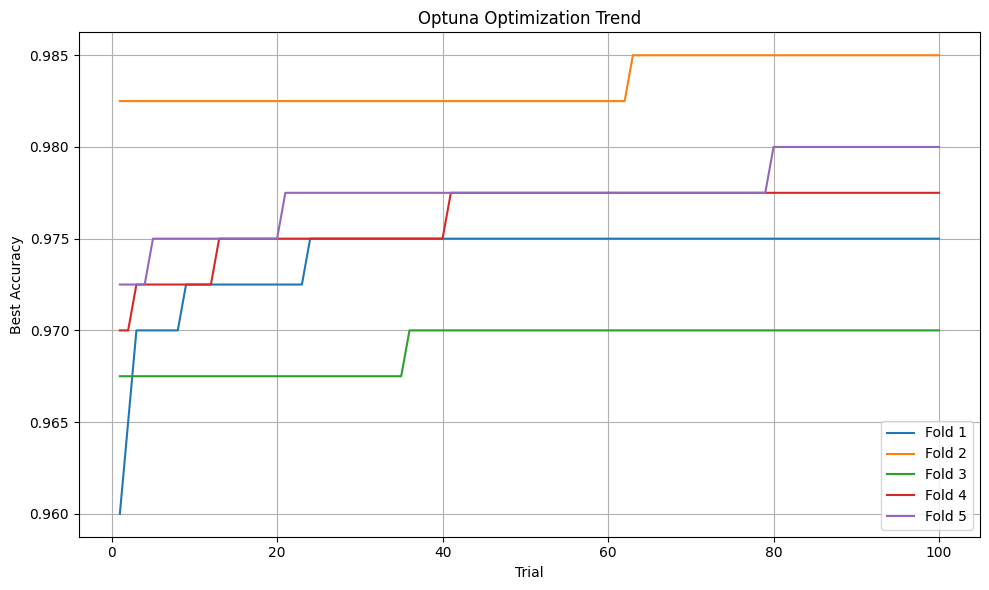

In [ ]:
plt.figure(figsize=(10, 6))

for i, study in enumerate(
    optuna_studies,
    1
):

    trial_accuracy = [
        trial.value
        for trial in study.trials
        if trial.value is not None
    ]

    best_so_far = []
    current_best = 0

    for acc in trial_accuracy:

        current_best = max(
            current_best,
            acc
        )

        best_so_far.append(
            current_best
        )

    plt.plot(
        range(1, len(best_so_far) + 1),
        best_so_far,
        label=f"Fold {i}"
    )


plt.xlabel("Trial")
plt.ylabel("Best Accuracy")

plt.title(
    "Optuna Optimization Trend"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Baseline SVM": baseline_df["accuracy"],
    "SVM + Hyperopt": hyperopt_df["accuracy"],
    "SVM + Optuna": optuna_df["accuracy"]
})

display(comparison)

,Baseline SVM,SVM + Hyperopt,SVM + Optuna
0,0.9600,0.9750,0.9750
1,0.9700,0.9825,0.9850
2,0.9450,0.9675,0.9700
3,0.9375,0.9775,0.9775
4,0.9450,0.9775,0.9800


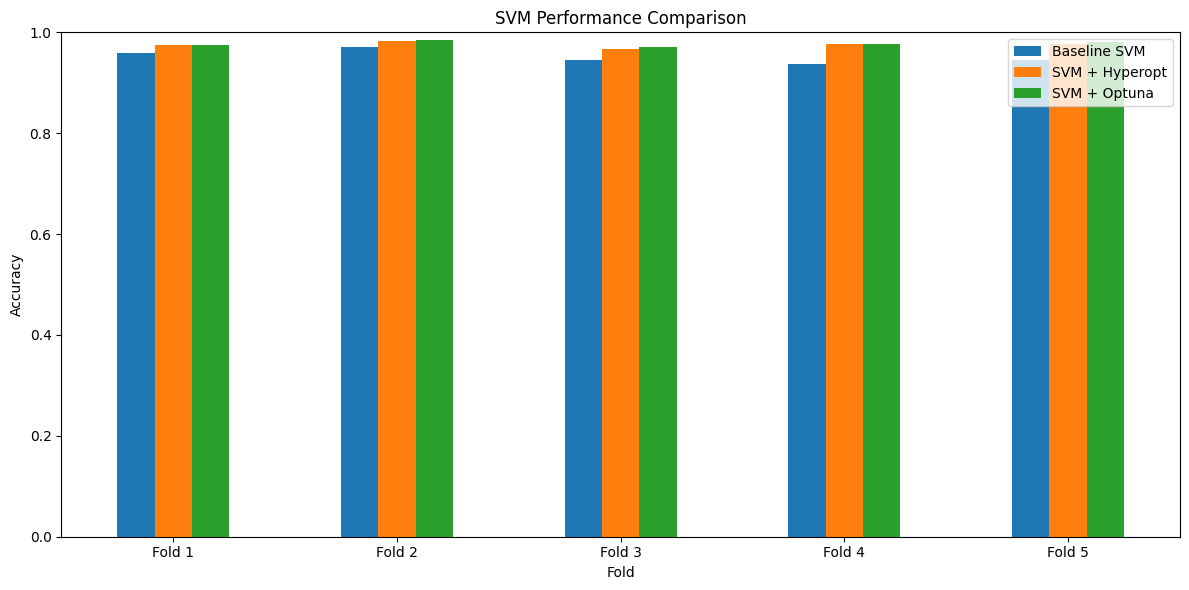

In [ ]:
comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "SVM Performance Comparison"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(
    range(5),
    [f"Fold {i}" for i in range(1, 6)],
    rotation=0
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
mean_comparison = {
    "Baseline SVM":
        baseline_df["accuracy"].mean(),

    "SVM + Hyperopt":
        hyperopt_df["accuracy"].mean(),

    "SVM + Optuna":
        optuna_df["accuracy"].mean()
}

print(mean_comparison)

{'Baseline SVM': np.float64(0.9515), 'SVM + Hyperopt': np.float64(0.976), 'SVM + Optuna': np.float64(0.9774999999999998)}


## Logistic Regression

To extend the SVM reproduction, Logistic Regression is added using the same 5-fold StratifiedKFold split.

Because Logistic Regression is sensitive to feature scale, `StandardScaler` is fitted only on each training fold through a `Pipeline`. This prevents information from the test fold from being used during scaling.

In [ ]:
# ============================================
# 1. Logistic Regression - Baseline
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

logistic_baseline_results = []
logistic_baseline_predictions = {}

for fold, (train_index, test_index) in enumerate(
    skf.split(X, y), 1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # StandardScaler is fitted only on the training data
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=2000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    logistic_baseline_predictions[fold] = {
        "y_test": y_test,
        "y_pred": y_pred
    }

    logistic_baseline_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, average="macro"
        ),
        "recall": recall_score(
            y_test, y_pred, average="macro"
        ),
        "f1": f1_score(
            y_test, y_pred, average="macro"
        )
    })

logistic_baseline_df = pd.DataFrame(
    logistic_baseline_results
)

print("\nLogistic Regression Baseline")
display(logistic_baseline_df)

print("\nMean:")
print(
    logistic_baseline_df.mean(
        numeric_only=True
    )
)

In [ ]:
# ============================================
# 2. Logistic Regression - Optuna
# ============================================

import optuna

logistic_optuna_results = []
logistic_optuna_studies = []

for fold, (train_index, test_index) in enumerate(
    skf.split(X, y), 1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # ----------------------------------------
    # Objective Function
    # ----------------------------------------

    def logistic_objective(trial):

        C = trial.suggest_float(
            "C",
            1e-4,
            100,
            log=True
        )

        solver = trial.suggest_categorical(
            "solver",
            ["lbfgs", "liblinear", "saga"]
        )

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("logistic", LogisticRegression(
                C=C,
                penalty="l2",
                solver=solver,
                max_iter=3000,
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        return accuracy_score(
            y_test,
            y_pred
        )

    # ----------------------------------------
    # Create Study
    # ----------------------------------------

    study = optuna.create_study(
        direction="maximize"
    )

    study.optimize(
        logistic_objective,
        n_trials=100
    )

    logistic_optuna_studies.append(study)

    # ----------------------------------------
    # Best Parameters
    # ----------------------------------------

    best_params = study.best_params

    print("Best parameters:")
    print(best_params)

    print(
        f"Best accuracy: {study.best_value:.4f}"
    )

    # ----------------------------------------
    # Train final Logistic Regression
    # ----------------------------------------

    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic", LogisticRegression(
            C=best_params["C"],
            penalty="l2",
            solver=best_params["solver"],
            max_iter=3000,
            random_state=42
        ))
    ])

    final_model.fit(
        X_train,
        y_train
    )

    y_pred = final_model.predict(
        X_test
    )

    # ----------------------------------------
    # Evaluation
    # ----------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    logistic_optuna_results.append({
        "fold": fold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "C": best_params["C"],
        "solver": best_params["solver"]
    })

    print(
        f"Test Accuracy: {accuracy:.4f}"
    )

logistic_optuna_df = pd.DataFrame(
    logistic_optuna_results
)

print("\nLogistic Regression + Optuna")
display(logistic_optuna_df)

print("\nMean:")
print(
    logistic_optuna_df.mean(
        numeric_only=True
    )
)

In [ ]:
# ============================================
# 3. Logistic Regression - Optuna Optimization Trend
# ============================================

plt.figure(figsize=(10, 6))

for i, study in enumerate(
    logistic_optuna_studies,
    1
):

    trial_accuracy = [
        trial.value
        for trial in study.trials
        if trial.value is not None
    ]

    best_so_far = []
    current_best = 0

    for acc in trial_accuracy:

        current_best = max(
            current_best,
            acc
        )

        best_so_far.append(
            current_best
        )

    plt.plot(
        range(1, len(best_so_far) + 1),
        best_so_far,
        label=f"Fold {i}"
    )

plt.xlabel("Trial")
plt.ylabel("Best Accuracy")

plt.title(
    "Logistic Regression - Optuna Optimization Trend"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 4. Logistic Regression - Baseline vs Optuna
# ============================================

logistic_comparison = pd.DataFrame({
    "Baseline Logistic Regression":
        logistic_baseline_df["accuracy"],

    "Logistic Regression + Optuna":
        logistic_optuna_df["accuracy"]
})

display(logistic_comparison)

logistic_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Baseline Logistic Regression vs Logistic Regression + Optuna"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(
    range(5),
    [f"Fold {i}" for i in range(1, 6)],
    rotation=0
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 5. SVM vs Logistic Regression
# ============================================

final_comparison = pd.DataFrame({
    "Baseline SVM":
        baseline_df["accuracy"],

    "SVM + Hyperopt":
        hyperopt_df["accuracy"],

    "SVM + Optuna":
        optuna_df["accuracy"],

    "Baseline Logistic Regression":
        logistic_baseline_df["accuracy"],

    "Logistic Regression + Optuna":
        logistic_optuna_df["accuracy"]
})

display(final_comparison)

final_comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "SVM vs Logistic Regression Performance Comparison"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(
    range(5),
    [f"Fold {i}" for i in range(1, 6)],
    rotation=0
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 6. Mean Accuracy Comparison
# ============================================

mean_comparison = {
    "Baseline SVM":
        baseline_df["accuracy"].mean(),

    "SVM + Hyperopt":
        hyperopt_df["accuracy"].mean(),

    "SVM + Optuna":
        optuna_df["accuracy"].mean(),

    "Baseline Logistic Regression":
        logistic_baseline_df["accuracy"].mean(),

    "Logistic Regression + Optuna":
        logistic_optuna_df["accuracy"].mean()
}

mean_comparison_df = pd.DataFrame(
    mean_comparison.items(),
    columns=["Model", "Mean Accuracy"]
)

display(mean_comparison_df)

plt.figure(figsize=(12, 6))

plt.bar(
    mean_comparison_df["Model"],
    mean_comparison_df["Mean Accuracy"]
)

plt.title(
    "Mean Accuracy Comparison"
)

plt.xlabel("Model")
plt.ylabel("Mean Accuracy")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

### Logistic Regression Interpretation

Logistic Regression provides a linear classification baseline for the multi-class `price_range` prediction task. Comparing it with SVM allows us to evaluate whether a linear decision boundary is sufficient or whether the nonlinear SVM models provide a meaningful performance improvement.

The Optuna version additionally tests different regularization strengths (`C`) and solvers to determine whether hyperparameter optimization improves the baseline Logistic Regression performance.

## Contribution